In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [18]:
from src.assets.output_dir import output_dir
from src.plotting_tools.cms_format import cms_format_fig, cms_style
from src.plotting_tools.SysHist import SysHist

cms_style()
outdir = output_dir

In [76]:
era = '2018'

In [77]:
##
## lumi
##

if era=='2016':
    lumi=1.025
    uncorr = 1.01
    corr_1 = 1.006
    corr_2 = 1.0
    lumi_str = f'''
lumi_uncorr_{era} lnN {uncorr}       -
lumi_corr1 lnN -      {corr_1}       -
'''
if era=='2017':
    lumi=1.023
    uncorr = 1.02
    corr_1 = 1.009
    corr_2 = 1.006
    lumi_str = f'''
lumi_uncorr_{era} lnN {uncorr}       -
lumi_corr1 lnN {corr_1}       -
lumi_corr2  lnN {corr_2}       -
'''
if era=='2018':
    lumi=1.025
    uncorr = 1.015
    corr_1 = 1.02
    corr_2 = 1.002
    lumi_str = f'''
lumi_uncorr_{era} lnN  {uncorr}       -
lumi_corr1 lnN  {corr_1}       -
lumi_corr2  lnN  {corr_2}       -
'''
print(lumi_str)


lumi_uncorr_2018 lnN  1.015       -
lumi_corr1 lnN  1.02       -
lumi_corr2  lnN  1.002       -



In [78]:
##
## closure
##

outname="{}/abcd/ABCD_closure_unc.pkl".format(outdir, era)
with open(outname, 'rb') as f:
    uncertainty_dict= pkl.load(f)
    
    
    print(pd.DataFrame(uncertainty_dict))
uncertainty_dict = {k:v+1 for k,v in uncertainty_dict[int(era)].items()}

     2016  2017  2018
SR1  0.23  0.17  0.17
SR2  0.19  0.21  0.17


In [79]:
injection_mass = 200
regex_str = f"abcd_dict_data_{era}_ismc0_v2_{injection_mass}_injection_sig_scale_([0-9]+p[0-9]+)"
injection_str = ['0p0', '0p2', '0p5', '1p0', '2p0', '4p0', '8p0', '16p0',]

abcds = {}
for injstr in injection_str:
    outname=f"{output_dir}/abcd/abcd_dict_data_{era}_ismc0_v2_{injection_mass}_injection_sig_scale_{injstr}.pkl"
    injection_num = float(injstr.replace('p', '.'))
    with open(outname,'rb') as f:
        abcd = pkl.load(f)
        
    abcds[injection_num] = abcd

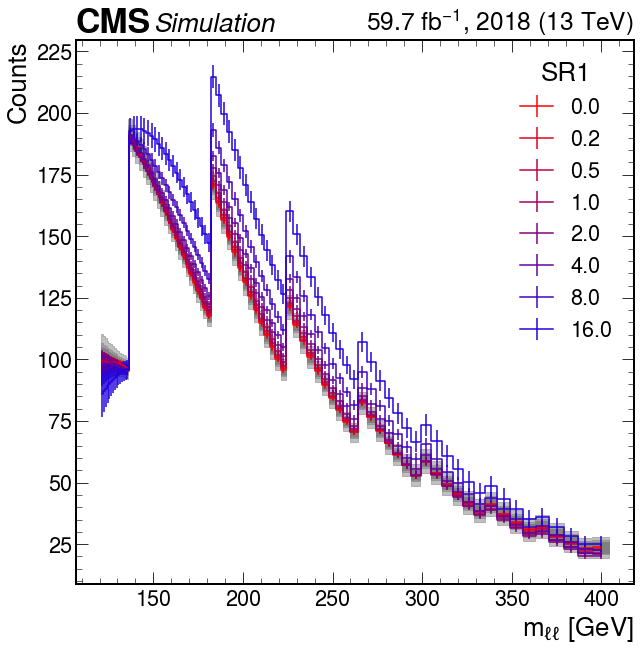

In [80]:
from src.plotting_tools.colors import color_fader

red = '#FF0000'
blue = '#0000FF'
reg = 'SR1'

fig, ax = plt.subplots()
for i, key in enumerate(abcds.keys()):
    mix = i/len(injection_str)
    color = color_fader(red, blue, mix=mix)

    SysHist.from_dict(abcds[key][reg]).draw(ax, label=key, color=color)
ax.legend(title=reg)

ax.set_xlabel('$m_{\ell\ell}$ [GeV]')
ax.set_ylabel('Counts')
cms_format_fig(era, ax, "Simulation")
# ax.set_yscale('log')
# ax.set_ylim(10**1, 10**3)

(300.0, 400.0)

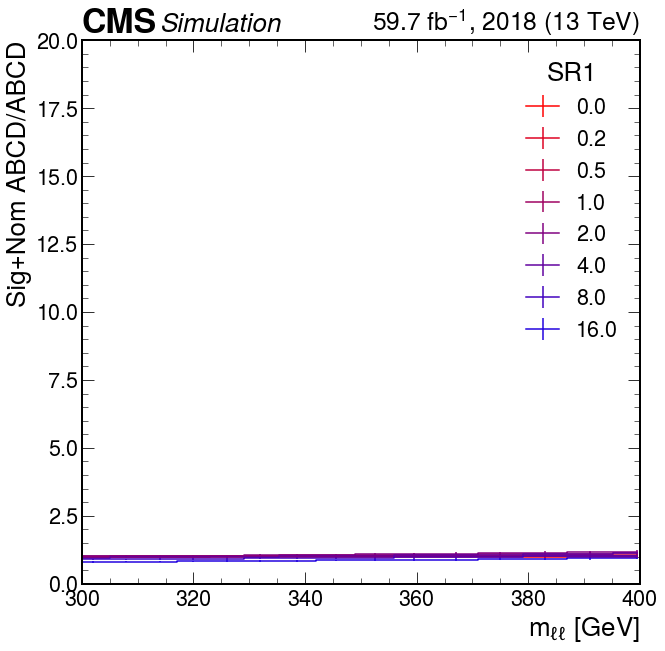

In [81]:
from src.plotting_tools.colors import color_fader

red = '#FF0000'
blue = '#0000FF'
reg = 'SR1'

fig, ax = plt.subplots()
for i, key in enumerate(abcds.keys()):
    mix = i/len(injection_str)
    color = color_fader(red, blue, mix=mix)
    abcd_hist = SysHist.from_dict(abcds[key][reg])
    sig_hist = abcds[key]["sig_"+reg].rebin(abcd_hist.bin_edges) + SysHist.from_dict(abcds[0.0][reg])
    sig_hist = sig_hist.calc_ratio(abcd_hist.nominal)
    sig_hist.draw(ax, label=key, color=color, draw_sys=False)
ax.legend(title=reg)

ax.set_xlabel('$m_{\ell\ell}$ [GeV]')
ax.set_ylabel('Sig+Nom ABCD/ABCD')
cms_format_fig(era, ax, "Simulation")
# ax.set_yscale('log')
ax.set_ylim(0,20)
ax.set_xlim(300,400)

(10, 3162.2776601683795)

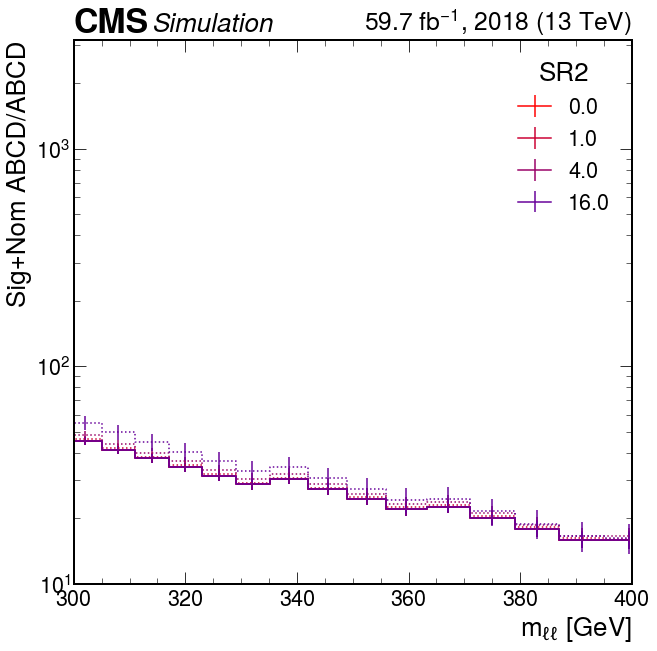

In [82]:
from src.plotting_tools.colors import color_fader

red = '#FF0000'
blue = '#0000FF'
reg = 'SR2'

fig, ax = plt.subplots()
for i, key in enumerate([0.0, 1.0, 4.0, 16.0]):
    mix = i/5.
    color = color_fader(red, blue, mix=mix)
    abcd_hist = SysHist.from_dict(abcds[key][reg])
    sig_hist = abcds[key]["sig_"+reg].rebin(abcd_hist.bin_edges) + SysHist.from_dict(abcds[0.0][reg])
    
    
    sig_hist.draw(ax, label=key, color=color, draw_sys=False)
    abcd_hist.draw(ax,  color=color, draw_sys=False, ls=':')
ax.legend(title=reg)

ax.set_xlabel('$m_{\ell\ell}$ [GeV]')
ax.set_ylabel('Sig+Nom ABCD/ABCD')
cms_format_fig(era, ax, "Simulation")
ax.set_yscale('log')
ax.set_xlim(300,400)
ax.set_ylim(10**1,10**3.5)

In [83]:
def array_from_df(_df, channel, process, systematic):
    _tdf = _df[(_df.channel==channel) & (_df.process==process) & (_df.systematic==systematic)]
    y = np.array(_tdf.sum_w)
    x = np.array(_tdf.bin)
    return x, y 

P-value: 0.41857863727180583
0.0 1.0243709814196187
P-value: 0.4618053190943939
0.2 1.0068429888849808
P-value: 0.5123460925016516
0.5 0.9868169823558484
P-value: 0.5466198405690107
1.0 0.9733641209084984
P-value: 0.5249347460437942
2.0 0.9818709140261251
P-value: 0.3508720509707056
4.0 1.0531643311219716
P-value: 0.0011257545400670266
8.0 1.5530171281576137
P-value: 1.0944957847841422e-25
16.0 3.6333503807057523
,key,chi2/ndof,p_value
0,0.0,1.024,0.419
1,0.2,1.007,0.462
2,0.5,0.987,0.512
3,1.0,0.973,0.547
4,2.0,0.982,0.525
5,4.0,1.053,0.351
6,8.0,1.553,0.001
7,16.0,3.633,0.0



,key,chi2/ndof,p_value
0,0.0,1.024,0.419
1,0.2,1.007,0.462
2,0.5,0.987,0.512
3,1.0,0.973,0.547
4,2.0,0.982,0.525
5,4.0,1.053,0.351
6,8.0,1.553,0.001
7,16.0,3.633,0.000


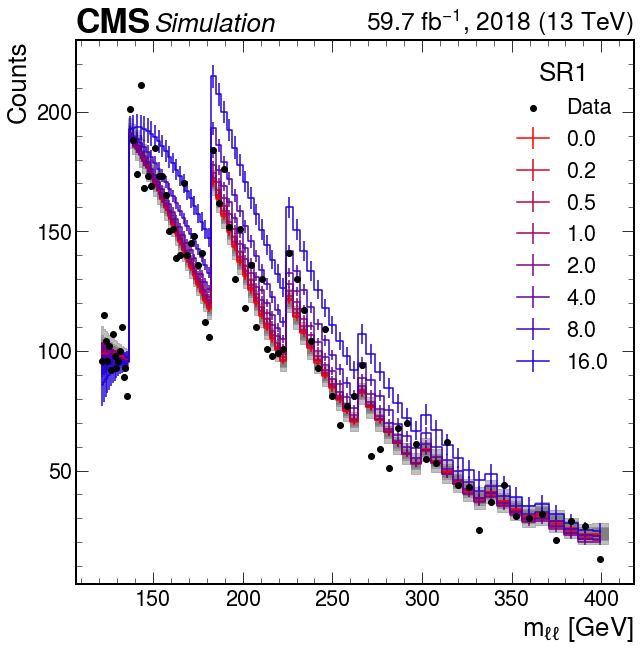

In [84]:
##
## chi2
##

from scipy.stats import chi2
stats_list = []

data_csv = f'{output_dir}/combine_data/correlated/{era}/{era}_nominal_abcd_shapes_df_input_{injection_mass}_injection_sig_scale_0p0.csv'
data_df = pd.read_csv(data_csv)

from src.plotting_tools.colors import color_fader

red = '#FF0000'
blue = '#0000FF'
reg = 'SR1'

dataX, dataY = array_from_df(data_df, reg, "data_obs", "nominal")

fig, ax = plt.subplots()

ax.scatter(dataX, dataY, label='Data', zorder=10, color='black')

for i, key in enumerate(abcds.keys()):
    mix = i/len(injection_str)
    color = color_fader(red, blue, mix=mix)
    hist = SysHist.from_dict(abcds[key][reg])
    hist.draw(ax, label=key, color=color)
    x, y = hist.calc_bin_centers(), hist.nominal
    unc = (y+(y*.04)**2)**.5
    chi2values = (y-dataY)**2/unc**2
    ndof = len(chi2values)-4 
    chi2values = np.sum(chi2values)

    # Calculate the p-value
    p_value = chi2.sf(chi2values, ndof)
    print("P-value:", p_value)
    print(key, chi2values/ndof)
    stats_list.append({"key": key, "chi2/ndof": chi2values/ndof, "p_value":p_value})

ax.legend(title=reg)


ax.set_xlabel('$m_{\ell\ell}$ [GeV]')
ax.set_ylabel('Counts')
cms_format_fig(era, ax, "Simulation")
# ax.set_yscale('log')
# ax.set_ylim(10**1, 10**3)

df = pd.DataFrame(stats_list)
print(df.round(3).to_csv())
df.round(3)

Text(1, 0, 'injection strength (multiples of limit level)')

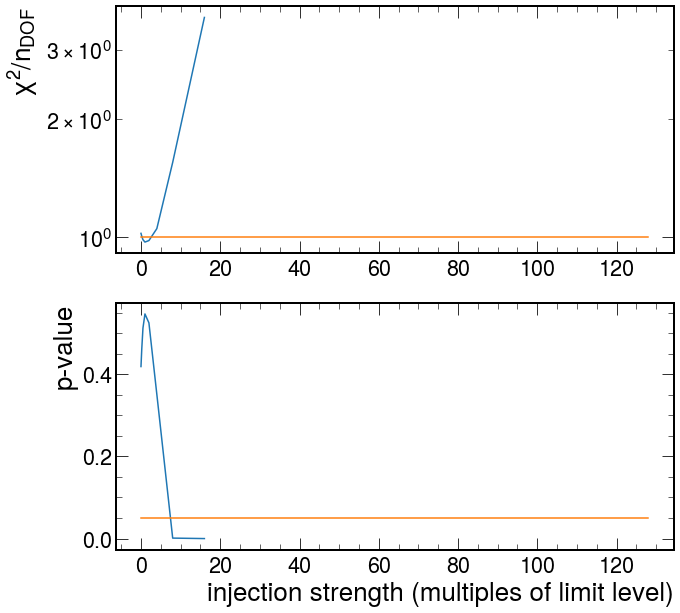

In [85]:
fig, axs = plt.subplots(2)
axs[0].plot(df.key, df['chi2/ndof'])
axs[0].set_yscale('log')
axs[0].set_ylabel('$\chi^2/n_{DOF}$')
axs[0].plot([0,128], [1,1])

axs[1].plot(df.key, df['p_value'])

axs[1].set_ylabel('p-value')

axs[1].plot([0,128], [0.05,0.05])
axs[1].set_xlabel('injection strength (multiples of limit level)')


In [86]:
def make_card(reg, process, abcd_injection_amount, data_injection_amount,
              use_fit_template=False, use_closure=False, fs_type='shape', 
              sig_inject='nominal'
             ):
    mass_dbs = re.findall('([0-9]+\.[0-9]+)_([0-9]+\.[0-9]+)_shape', process)[0]
    mass, dbs = float(mass_dbs[0]), float(mass_dbs[1]),
    sig_name = process
    closure = uncertainty_dict[reg]
    
    
    tadf = acc_df[(acc_df.mass==mass) & (acc_df.type==fs_type) & (acc_df.reg==reg)]

    isrfsrUp, isrfsrDowm = tadf[['Weight_ISRFSR_Up', 'Weight_ISRFSR_Down']].iloc[0]
    isrfsrUp, isrfsrDowm = sorted((isrfsrUp, isrfsrDowm))
    isrfsrUp = "{:.2f}".format(isrfsrUp+1)
    isrfsrDowm = "{:.2f}".format(isrfsrDowm+1)
    
    pdfUp, pdfDown = tadf[['Weight_PDF_Up', 'Weight_PDF_Down']].iloc[0]
    pdfUp, pdfDown = sorted((pdfUp, pdfDown))
    pdfUp = "{:.2f}".format(pdfUp+1)
    pdfDown = "{:.2f}".format(pdfDown+1)
    
    

    template=f'''imax 1
jmax 1
kmax *
--------------------------------------------------------------------------------
shapes * * {era}/{era}_abcd_shapes_df_input_{injection_mass}_injection_sig_scale_{abcd_injection_amount}.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
shapes {sig_name} * {era}/{era}_{process}_signal_shapes_df_input.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
shapes data_obs * {era}/{era}_nominal_abcd_shapes_df_input_{injection_mass}_injection_sig_scale_{data_injection_amount}.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
--------------------------------------------------------------------------------
bin         {reg}
observation -1
--------------------------------------------------------------------------------
bin             {reg}   {reg}
process         {sig_name} ABCD
process         0      1
rate            -1     -1
--------------------------------------------------------------------------------
Weight_PDF_ lnN  {pdfUp}/{pdfDown}      -
Weight_ISRFSR_ lnN {isrfsrUp}/{isrfsrDowm}      -
'''

    '''
jesTotal shapeN2 1       -
Weight_Pu shapeN2 1       -
jerTotal shapeN2 1       -
Weight_Pu shapeN2 1       -
Weight_BTagCorr shapeN2 1       -
Weight_BTagUncorr_{era} shapeN2 1       -
Weight_PUID shapeN2 1       -
Weight_PDF_ lnN  {pdfUp}/{pdfDown}      -
Weight_ISRFSR_ lnN {isrfsrUp}/{isrfsrDowm}      -
Weight_MuonSF shapeN2 1       -
Weight_L1 shapeN2 1       -
Weight_MuonTrigger shapeN2 1       -

'''
    for sig_sys in signal_df.systematic.unique():
            if sig_sys == 'nominal': continue
            if 'Up' in sig_sys: continue
            sig_sys = sig_sys.replace('Down', '')
            template+=f"{sig_sys} shapeN2 1       -\n"
        
    if use_fit_template:
        for fit_sys in not_signal_df.systematic.unique():
            if fit_sys == 'nominal': continue
            if 'Up' in fit_sys: continue
            fit_sys = fit_sys.replace('Down', '')
            template+=f"{fit_sys} shapeN2 -       1\n"
            
    if use_closure:
        template+=f"Closure_{era} lnU -         {closure}\n"
        
    template+=lumi_str
    
    return template, mass, dbs

In [87]:
acc_csv = f'{output_dir}/combine_data/correlated/{era}/{era}_accpt_df_interpolated.csv'
acc_df = pd.read_csv(acc_csv)
signal_csv  = f'{output_dir}/combine_data/correlated/{era}/{era}_signal_shapes_df_input.csv'
signal_df = pd.read_csv(signal_csv)


not_signal_csvname = f'{output_dir}/combine_data/correlated/{era}/{era}_abcd_shapes_df_input.csv'
not_signal_df = pd.read_csv(not_signal_csvname)


In [88]:
signal_df.process.unique()

array(['125.0_0.5_shape', '126.7_0.5_shape', '128.4_0.5_shape',
       '130.2_0.5_shape', '132.0_0.5_shape', '133.8_0.5_shape',
       '135.7_0.5_shape', '137.6_0.5_shape', '139.5_0.5_shape',
       '141.5_0.5_shape', '143.5_0.5_shape', '145.6_0.5_shape',
       '147.7_0.5_shape', '149.9_0.5_shape', '152.1_0.5_shape',
       '154.4_0.5_shape', '156.7_0.5_shape', '159.1_0.5_shape',
       '161.5_0.5_shape', '164.0_0.5_shape', '166.5_0.5_shape',
       '169.1_0.5_shape', '171.7_0.5_shape', '174.4_0.5_shape',
       '177.2_0.5_shape', '180.0_0.5_shape', '182.9_0.5_shape',
       '185.9_0.5_shape', '188.9_0.5_shape', '192.0_0.5_shape',
       '195.2_0.5_shape', '198.4_0.5_shape', '201.7_0.5_shape',
       '205.1_0.5_shape', '208.6_0.5_shape', '212.2_0.5_shape',
       '215.8_0.5_shape', '219.5_0.5_shape', '223.3_0.5_shape',
       '227.2_0.5_shape', '231.2_0.5_shape', '235.3_0.5_shape',
       '239.5_0.5_shape', '243.8_0.5_shape', '248.2_0.5_shape',
       '252.7_0.5_shape', '257.4_0.5_sha

In [89]:
process = "198.4_0.5_shape"
reg = 'SR1'
run_string = ""
file_names = []
for data_inj in injection_str:
    for abcd_inj in injection_str:
        template, mass, dbs = make_card(reg, process, abcd_inj, data_inj, use_fit_template=True)
        dc_name = f'{era}_{reg}_{process}_abcd_{abcd_inj}_data_{data_inj}.txt'
        with open(f'{output_dir}/combine_data/correlated/{era}/{dc_name}', 'w') as f: 
            f.write(template)
            
        run_string += f"echo '{dc_name}'\n"
        run_string += f"combine -M AsymptoticLimits {era}/{dc_name} > {dc_name}\n"
        file_names.append(f'{output_dir}/combine_data/correlated/{dc_name}')

In [94]:
file_names[0]

'/eos/cms/store/group/phys_exotica/bffZprime/assets_june_23/combine_data/correlated/2018_SR1_198.4_0.5_shape_abcd_0p0_data_0p0.txt'

In [ ]:
with open(f'{output_dir}/combine_data/correlated/run.sh', 'w') as f: 
    f.write(run_string)
print(run_string)

In [91]:
def get_data_from_file(f):
    match = re.findall('shape_abcd_([0-9]+p[0-9]+)_data_([0-9]+p[0-9]+)',file)
    abcd_inj = float(match[0][0].replace('p','.'))
    data_inj = float(match[0][1].replace('p','.'))
    with open(f, 'r') as _f:
        r = _f.read()
        limits = re.findall(r'Expected +(\d+.\d+)%: r < (\d+.\d+)',r)
        limits = {float(x): float(y) for (x,y) in limits}
        obs = re.findall(r'Observed Limit: r < (\d+.\d+)',r)
        if len(obs)==1: obs = float(obs[0])
        else: obs = 0
        
    return {"abcd_inj":abcd_inj,"data_inj":data_inj,  "obs": obs, **limits}

In [92]:
limit_list = []
for file in file_names:
    limits = get_data_from_file(file)
    limit_list.append(limits)

FileNotFoundError: [Errno 2] No such file or directory: '/eos/cms/store/group/phys_exotica/bffZprime/assets_june_23/combine_data/correlated/2018_SR1_198.4_0.5_shape_abcd_0p0_data_0p0.txt'

In [93]:
df = pd.DataFrame(limit_list)


In [ ]:
tdf_same = df[df.abcd_inj==df.data_inj]

tdf_same

In [ ]:
tdf_muon_only = df[df.abcd_inj==0]
tdf_muon_only

In [ ]:
tdf_muon_only.obs.to_numpy()/tdf_same.obs.to_numpy()

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(20,20))

ax = axs[0][0]
ax.scatter(tdf_muon_only.data_inj, tdf_muon_only.obs.to_numpy(), label='Muon Only')
ax.scatter(tdf_muon_only.data_inj, tdf_same.obs.to_numpy(), label='Universal Decay')
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlabel('Injeciton Size/Nominal Expected Limit')
ax.set_ylabel('Obs. Limits')
ax.legend(title=reg)
cms_format_fig(era, ax, "Simulation")

ax = axs[1][0]
ax.scatter(tdf_muon_only.data_inj, tdf_muon_only.obs.to_numpy(), label='Muon Only')
ax.scatter(tdf_muon_only.data_inj, tdf_same.obs.to_numpy(), label='Universal Decay')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Injeciton Size/Nominal Expected Limit')
ax.set_ylabel('Obs. Limits')
ax.legend(title=reg)
cms_format_fig(era, ax, "Simulation")

ax = axs[0][1]

ax.scatter(tdf_muon_only.data_inj, tdf_muon_only.obs.to_numpy()/tdf_same.obs.to_numpy())
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Injeciton Size/Nominal Expected Limit')
ax.set_ylabel('Ratio of Limits for Muon Only to Universal Decay')
ax.legend(title=reg)
cms_format_fig(era, ax, "Simulation")


ax = axs[1][1]

ax.scatter(tdf_muon_only.data_inj, tdf_muon_only.obs.to_numpy()/tdf_same.obs.to_numpy())
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Injeciton Size/Nominal Expected Limit')
ax.set_ylabel('Ratio of Limits for Muon Only to Universal Decay')
ax.legend(title=reg)
cms_format_fig(era, ax, "Simulation")

In [ ]:
##
## Test fit statistics
##

import uproot 
path = '/eos/cms/store/group/phys_exotica/bffZprime/assets_june_23/combine_data/correlated/fitDiagnosticsTest.root'

file = uproot.open(path)

In [ ]:
fitdiagnostics/$1

In [98]:
dir_list = []
print(make_run_list(reg, mass, CR_injection="0p0", SR_injection = '0p0'))

combine -M FitDiagnostics  2018/SR1_198.4_0.5_shape_abcd_0p0_data_0p0.txt --plots
    mkdir 2018_SR1_198.4_0p0_0p0
    cp fitDiagnosticsTest.root 2018_SR1_198.4_0p0_0p0
    cp *.png 2018_SR1_198.4_0p0_0p0
    cp  combine_logger.out 2018_SR1_198.4_0p0_0p0
    cp  higgsCombineTest.FitDiagnostics.mH120.root 2018_SR1_198.4_0p0_0p0
    


In [95]:
def make_run_list(reg, mass, CR_injection="0p0", SR_injection = '0p0'):
    directory = f"{era}_{reg}_{mass}_{CR_injection}_{SR_injection}"
    dir_list.append(directory)
    string = f'''combine -M FitDiagnostics  2018/{reg}_{mass}_0.5_shape_abcd_{CR_injection}_data_{SR_injection}.txt --plots
    mkdir {directory}
    cp fitDiagnosticsTest.root {directory}
    cp *.png {directory}
    cp  combine_logger.out {directory}
    cp  higgsCombineTest.FitDiagnostics.mH120.root {directory}
    '''
    return string
    
    

In [ ]:
mass = "351.8"
regs = ['SR1', 'SR2']
run_string = ""
dir_list = []
injections = ['0p0','0p2', '0p5', '1p0', '2p0', '4p0', '8p0', '16p0', '32p0', '64p0', '128p0']
for inj in injections:
    for reg in regs:
        run_string+=make_run_list(reg, mass, CR_injection=inj)
    
injections = ['0p0','0p2', '0p5', '1p0', '2p0', '4p0', '8p0', '16p0', '32p0', '64p0', '128p0']
for inj in injections:
    for reg in regs:
        run_string+=make_run_list(reg, mass, CR_injection=inj, SR_injection = inj)

with open(f'{output_dir}/combine_data/correlated/run_fit_diagnostics.sh', 'w') as f: 
    f.write(run_string)
print(run_string)

In [ ]:
import ROOT

In [ ]:
import ctypes
def extract_rooplot_data(curve):

    # Initialize lists to store x and y values
    x_vals = []
    y_vals = []
    
    # Loop over the points in the curve (for example)
    for i in range(curve.GetN()):
        x = ctypes.c_double(0)  # ctypes double for x
        y = ctypes.c_double(0)  # ctypes double for y
        curve.GetPoint(i, x, y)
        x_vals.append(x.value)  # Access the value stored in ctypes double
        y_vals.append(y.value)  # Access the value stored in ctypes double
    
    
    # Convert lists to numpy arrays
    x_array = np.array(x_vals)
    y_array = np.array(y_vals)
    
    return x_array, y_array

In [ ]:
# Assuming 'frame' is your RooPlot object
def extract_rooplot_data_curve(curve):
    # Initialize lists to store x and y values
    x_vals = []
    y_vals = []

    # Loop over the points in the curve (for example)
    for i in range(curve.GetN()):
        x = ctypes.c_double(0)  # ctypes double for x
        y = ctypes.c_double(0)  # ctypes double for y
        curve.GetPoint(i, x, y)
        x_vals.append(x.value)
        y_vals.append(y.value)
    
    # Convert lists to numpy arrays
    x_array = np.array(x_vals)
    y_array = np.array(y_vals)
    
    return x_vals, y_vals

In [ ]:
import re

In [ ]:
def get_hists(directory):
    
    reg, CR_inj, SR_inc = re.findall('(SR1|SR2)_[0-9]+.[0-9]+_([0-p]+p[0-9]+)_([0-9]+p[0-9]+)', directory)[0]
    CR_inj = float(CR_inj.replace('p','.'))
    SR_inj = float(SR_inc.replace('p','.'))

    fname = f'{output_dir}/combine_data/correlated/{directory}/fitDiagnosticsTest.root'
    file = ROOT.TFile.Open(fname)
    hist = file.Get(f'{reg}_CMS_th1x_fit_b')
    hist.Print("v")
    getCurve = hist.getCurve(f"pdf_bin{reg}__model_bonly__Norm[CMS_th1x]_Comp[shapeBkg*]")

    xc, yc = extract_rooplot_data_curve(getCurve)
    
        # Get the RooCurve or RooHist from the RooPlot (by name or index)
    histcurve = hist.getHist(f"h_{reg}")  # Assuming a curve exists, or use frame.getHist() for a histogram
    
    xb, yb = extract_rooplot_data(histcurve)
    plt.plot(xb, yb)
    plt.plot(xc, yc)

    result_dict = {"chiSquare":hist.chiSquare(), 
                   "xc": xc, "yc": yc, "xb": xb, "yb": yb,
                  "SR_inj": SR_inj, "CR_inj":CR_inj,
                  "reg": reg}
    return result_dict

fit_list = []
for directory in dir_list:
    try:
        fit_list.append(get_hists(directory) )
    except:
        continue


In [ ]:
df = pd.DataFrame(fit_list)

from scipy.stats import chi2
# = chi2.sf(chi2values, ndof)
ndof = len(fit_list[0]['xb'])
df['pValue'] = df.chiSquare.apply(lambda x: chi2.sf(x*ndof, ndof))

In [ ]:
reg = 'SR2'

In [ ]:
tdf = df[df.reg==reg]
tdf[['reg', 'chiSquare', 'SR_inj', 'CR_inj', 'pValue']].round(3)

In [ ]:
fig, ax = plt.subplots()

tdf = tdf[(tdf.SR_inj==0)]
count = 0
for i, row in tdf.iterrows():
    mix = count/len(injection_str)
    count+=1
    color = color_fader(red, blue, mix=mix)
    ax.plot(row.xc, row.yc, label=f"{row.CR_inj}:{row.chiSquare:.2f}", color=color)
    if row.chiSquare> 2: break
   
ax.scatter(row.xb, row.yb)
ax.legend(title=reg)
cms_format_fig(era, ax, "Preliminary")
ax.set_xlabel('Bins')
ax.set_ylabel('Counts')

In [ ]:
from scipy.optimize import curve_fit
def chi2Fit(x, x0, p, q, offset):
    return (1+(x/x0)**p)**(1/q)

In [ ]:
fig, axs = plt.subplots(2)



ax = axs[0]
tdf = tdf.sort_values("CR_inj")
ax.plot(tdf.CR_inj, tdf.chiSquare )

#fit
x = np.linspace(0,max(tdf.CR_inj), 100)
func = taylor_series
p0 = [1,1,1,1]
popt, pcov = curve_fit(func,tdf.CR_inj, tdf.chiSquare,
                       p0=p0)
ax.plot(x,func(x, *popt))

ax.plot([0,128], [1,1], label='$\chi^2/n_{DOF}$==1')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(title=reg)
cms_format_fig(era, ax, "")
ax.set_ylabel('$\chi^2/n_{DOF}$')



ax = axs[1]
tdf = tdf.sort_values("CR_inj")
ax.plot(tdf.CR_inj, tdf.pValue )
ax.plot([0,128], [0.05,0.05], label='p=0.05')

#fit 
p_fit = chi2.sf(func(x, *popt)*ndof, ndof)
ax.plot(x,p_fit)

ax.set_xscale('log')
ax.set_xlabel('Injeciton Size/Nominal Expected Limit')
ax.set_ylabel('p-Value')
ax.legend()


In [ ]:
break

In [166]:
file = ROOT.TFile.Open(path)

In [199]:
hist = file.Get('SR1_CMS_th1x_fit_b')

In [200]:
getHist = hist.getHist("pdf_binSR1__model_bonly__Norm[CMS_th1x]_Comp[shapeBkg*]")

In [201]:
getCurve = hist.getCurve("pdf_binSR1__model_bonly__Norm[CMS_th1x]_errorband")

In [203]:
xb, yb = extract_rooplot_data_curve(getCurve)

In [204]:
hist.Print("v")

RooPlot SR1_CMS_th1x (SR1) plots variable CMS_th1x "CMS_th1x"
  Plot frame contains 6 object(s):
    [0] (Options="P") RooHist::h_SR1 
    [1] (Options="F") RooCurve::pdf_binSR1__model_bonly__Norm[CMS_th1x]_errorband 
    [2] (Options="L") RooCurve::pdf_binSR1__model_bonly__Norm[CMS_th1x]_Comp[shapeSig*] 
    [3] (Options="L") RooCurve::pdf_binSR1__model_bonly__Norm[CMS_th1x]_Comp[shapeBkg*] 
    [4] (Options="L") RooCurve::pdf_binSR1__model_bonly__Norm[CMS_th1x] 
    [5] (Options="P") RooHist::h_SR1 


In [205]:
hist.chiSquare()
import numpy as np

In [206]:
import ctypes
def extract_rooplot_data(frame):
    # Get the RooCurve or RooHist from the RooPlot (by name or index)
    curve = frame.getHist("h_SR1")  # Assuming a curve exists, or use frame.getHist() for a histogram
    
    # Initialize lists to store x and y values
    x_vals = []
    y_vals = []
    
    # Loop over the points in the curve (for example)
    for i in range(curve.GetN()):
        x = ctypes.c_double(0)  # ctypes double for x
        y = ctypes.c_double(0)  # ctypes double for y
        curve.GetPoint(i, x, y)
        x_vals.append(x.value)  # Access the value stored in ctypes double
        y_vals.append(y.value)  # Access the value stored in ctypes double
    
    
    # Convert lists to numpy arrays
    x_array = np.array(x_vals)
    y_array = np.array(y_vals)
    
    return x_array, y_array

In [207]:
x, y = extract_rooplot_data(hist)

2.128180560711372

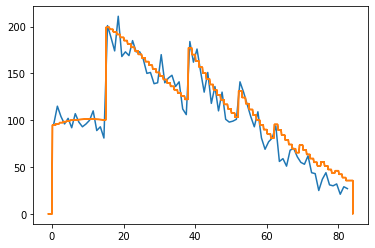

In [208]:
plt.plot(x,y)
plt.plot(xb, yb)
hist.chiSquare()

1.0183442942724017

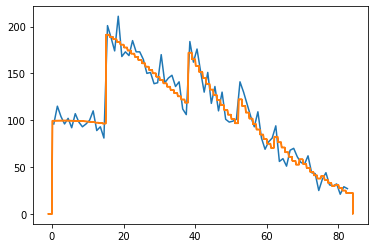

In [143]:
plt.plot(x,y)
plt.plot(xb, yb)
hist.chiSquare()

In [ ]:
fig, ax = plt.subplots()

ax.scatter(tdf_muon_only.data_inj, tdf_muon_only.obs.to_numpy()/tdf_same.obs.to_numpy())
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Injeciton Size/Nominal Expected Limit')
ax.set_ylabel('Ratio of Limits for Muon Only to Universal Decay')
ax.legend(title=reg)
cms_format_fig(era, ax, "Simulation")

In [ ]:
fig, ax = plt.subplots()

ax.scatter(tdf_muon_only.data_inj, tdf_muon_only.obs.to_numpy()/tdf_same.obs.to_numpy())
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Injeciton Size/Nominal Expected Limit')
ax.set_ylabel('Ratio of Limits for Muon Only to Universal Decay')

In [ ]:
break

In [ ]:
ll /eos/cms/store/group/phys_exotica/bffZprime/assets_june_23/combine_data/correlated/2018/2018_nominal_abcd_shapes_df_input_125_injection_sig_scale_128p0.csv

In [ ]:
signal_csv  = f'{output_dir}/combine_data/correlated/{era}/{era}_signal_shapes_df_input.csv'
not_signal_csvname = f'{output_dir}/combine_data/correlated/{era}/{era}_abcd_shapes_df_input.csv'
acc_csv = f'{output_dir}/combine_data/correlated/{era}/{era}_accpt_df_interpolated.csv'

data_csv = f'{output_dir}/combine_data/correlated/{era}/{era}_nominal_abcd_shapes_df_input_125_injection_sig_scale_128p0.csv'

In [ ]:
signal_csv

In [ ]:
signal_df = pd.read_csv(signal_csv)
not_signal_df = pd.read_csv(not_signal_csvname)
acc_df = pd.read_csv(acc_csv)
data_df = pd.read_csv(data_csv)

In [ ]:
not_signal_df[not_signal_df.bin==121.5]

In [ ]:
def array_from_df(_df, channel, process, systematic):
    _tdf = _df[(_df.channel==channel) & (_df.process==process) & (_df.systematic==systematic)]
    y = np.array(_tdf.sum_w)
    x = np.array(_tdf.bin)
    return x, y 

In [ ]:
signal_df

In [ ]:
signal_masses, signal = array_from_df(signal_df, channel='SR1', process='351.8_0.5_shape', systematic='nominal')
abcd_masses, abcd = array_from_df(not_signal_df, channel='SR1', 
                                  process='ABCD', systematic='nominal')
data_masses, data = array_from_df(data_df, channel='SR1', 
                                  process='data_obs', systematic='nominal')



_, abcd_Up = array_from_df(not_signal_df, channel='SR1', 
                                  process='ABCD', systematic=f'fit_272_{era}_Up')
_, abcd_Down = array_from_df(not_signal_df, channel='SR1', 
                                  process='ABCD', systematic=f'fit_272_{era}_Down')


fig, axs = plt.subplots(2)

axs[0].scatter(signal_masses, signal)
axs[0].scatter(data_masses, data)

axs[0].scatter(abcd_masses, abcd)
axs[0].scatter(abcd_masses, abcd_Up, label='Up')
axs[0].scatter(abcd_masses, abcd_Down, label='Down')

axs[1].scatter(abcd_masses, signal/abcd)
axs[0].legend()

signal.sum()

In [ ]:
def make_card(reg, process, use_fit_template=False, use_closure=False, fs_type='shape', 
              sig_inject='nominal'):
    mass_dbs = re.findall('([0-9]+\.[0-9]+)_([0-9]+\.[0-9]+)_shape', process)[0]
    mass, dbs = float(mass_dbs[0]), float(mass_dbs[1]),
    sig_name = process
    closure = uncertainty_dict[reg]
    
    
    tadf = acc_df[(acc_df.mass==mass) & (acc_df.type==fs_type) & (acc_df.reg==reg)]

    isrfsrUp, isrfsrDowm = tadf[['Weight_ISRFSR_Up', 'Weight_ISRFSR_Down']].iloc[0]
    isrfsrUp, isrfsrDowm = sorted((isrfsrUp, isrfsrDowm))
    isrfsrUp = "{:.2f}".format(isrfsrUp+1)
    isrfsrDowm = "{:.2f}".format(isrfsrDowm+1)
    
    pdfUp, pdfDown = tadf[['Weight_PDF_Up', 'Weight_PDF_Down']].iloc[0]
    pdfUp, pdfDown = sorted((pdfUp, pdfDown))
    pdfUp = "{:.2f}".format(pdfUp+1)
    pdfDown = "{:.2f}".format(pdfDown+1)
    
    

    template=f'''imax 1
jmax 1
kmax *
--------------------------------------------------------------------------------
shapes * * {era}/{era}_abcd_shapes_df_input.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
shapes {sig_name} * {era}/{era}_{process}_signal_shapes_df_input.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
shapes data_obs * {era}/{era}_nominal_abcd_shapes_df_input.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
--------------------------------------------------------------------------------
bin         {reg}
observation -1
--------------------------------------------------------------------------------
bin             {reg}   {reg}
process         {sig_name} ABCD
process         0      1
rate            -1     -1
--------------------------------------------------------------------------------
Weight_PDF_ lnN  {pdfUp}/{pdfDown}      -
Weight_ISRFSR_ lnN {isrfsrUp}/{isrfsrDowm}      -
'''

    '''
jesTotal shapeN2 1       -
Weight_Pu shapeN2 1       -
jerTotal shapeN2 1       -
Weight_Pu shapeN2 1       -
Weight_BTagCorr shapeN2 1       -
Weight_BTagUncorr_{era} shapeN2 1       -
Weight_PUID shapeN2 1       -
Weight_PDF_ lnN  {pdfUp}/{pdfDown}      -
Weight_ISRFSR_ lnN {isrfsrUp}/{isrfsrDowm}      -
Weight_MuonSF shapeN2 1       -
Weight_L1 shapeN2 1       -
Weight_MuonTrigger shapeN2 1       -

'''
    for sig_sys in signal_df.systematic.unique():
            if sig_sys == 'nominal': continue
            if 'Up' in sig_sys: continue
            sig_sys = sig_sys.replace('Down', '')
            template+=f"{sig_sys} shapeN2 1       -\n"
            
    if use_fit_template:
        for fit_sys in not_signal_df.systematic.unique():
            if fit_sys == 'nominal': continue
            if 'Up' in fit_sys: continue
            fit_sys = fit_sys.replace('Down', '')
            template+=f"{fit_sys} shapeN2 -       1\n"
            
    if use_closure:
        template+=f"Closure_{era} lnU -         {closure}\n"
        
    template+=lumi_str
    
    return template, mass, dbs

In [ ]:
run_string = ""
multi = acc_df.type.unique()
for reg in ['SR1', 'SR2']:
    for process in signal_df.process.unique():
        for fstype in multi:
            use_closure = False
            use_fit_template = True 
            template, mass, dbs = make_card(reg, process,
                                    use_fit_template=use_fit_template,use_closure=use_closure,
                                           fs_type=fstype)
            
            
            fstype = fstype.replace('(','_').replace(')','')
            dc_name = f'{fstype}_{reg}_{process}_closure_{use_closure}_fit_template_{use_fit_template}.txt'
            with open(f'{output_dir}/combine_data/correlated/{era}/{dc_name}', 'w') as f: 
                f.write(template)
            
            run_string += f"echo '{dc_name}'\n"
            run_string += f"combine -M AsymptoticLimits {era}/{dc_name}\n"
print(run_string)

In [ ]:
path = '{}/combine_data/correlated'.format(outdir)
path

In [ ]:
run_combine = '''#!/bin/sh
#ulimit -s unlimited
#set -e
cd /afs/cern.ch/work/r/rymuelle/public/nanoAODzPrime/higgscombine/CMSSW_10_2_13/src
export SCRAM_ARCH=slc7_amd64_gcc700
source /cvmfs/cms.cern.ch/cmsset_default.sh
eval `scramv1 runtime -sh`
cd {path} 

combine -M AsymptoticLimits "$1"

'''.format(path=path)

In [ ]:
!mkdir {path}
!mkdir {path}/{era}

In [ ]:
!cp src/combine_scripts/* {path}

In [ ]:
with open('{}/run_combine.sh'.format(path), 'w') as f:
    f.write(run_combine)

In [ ]:
path = '/afs/cern.ch/work/r/rymuelle/public/nanoAODzPrime/CMSSW_12_1_0/src/bff_plotting_code_v3/combine_data/correlated'

In [ ]:
!mkdir {path}/out
!mkdir {path}/err
!mkdir {path}/log

!mkdir {path}/out/2016
!mkdir {path}/err/2016
!mkdir {path}/log/2016

!mkdir {path}/out/2017
!mkdir {path}/err/2017
!mkdir {path}/log/2017


!mkdir {path}/out/2018
!mkdir {path}/err/2018
!mkdir {path}/log/2018


!mkdir {path}/out/201X
!mkdir {path}/err/201X
!mkdir {path}/log/201X

In [ ]:
##
## combine eras
##

In [ ]:
for reg in ['SR1', 'SR2']:
    for process in signal_df.process.unique():
        for fstype in multi:
            fstype = fstype.replace('(','_').replace(')','')
            combine_sh ='combineCards.py '
            i = 0
            for _era in [2016, 2017, 2018]:
                dc_name = f'{fstype}_{reg}_{process}_closure_{use_closure}_fit_template_{use_fit_template}.txt'
                combine_sh += f" Name{i}={_era}/{dc_name}"
                i+=1
            
            dc_name = f'{fstype}_{reg}_{process}_closure_{use_closure}_fit_template_{use_fit_template}.txt'
            combine_sh += f' > 201X/{dc_name}'
            print(combine_sh)

In [ ]:
##
## bff
## 

In [ ]:
def make_card(reg, process, use_fit_template=False, use_closure=False, fs_type='shape', 
              sig_inject='nominal'):
    mass_dbs = re.findall('([0-9]+\.[0-9]+)_([0-9]+\.[0-9]+)_shape', process)[0]
    mass, dbs = float(mass_dbs[0]), float(mass_dbs[1]),
    sig_name = process
    closure = uncertainty_dict[reg]
    
    
    tadf = acc_df[(acc_df.mass==mass) & (acc_df.type==fs_type) & (acc_df.reg==reg)]

    isrfsrUp, isrfsrDowm = tadf[['Weight_ISRFSR_Up', 'Weight_ISRFSR_Down']].iloc[0]
    isrfsrUp, isrfsrDowm = sorted((isrfsrUp, isrfsrDowm))
    isrfsrUp = "{:.2f}".format(isrfsrUp+1)
    isrfsrDowm = "{:.2f}".format(isrfsrDowm+1)
    
    pdfUp, pdfDown = tadf[['Weight_PDF_Up', 'Weight_PDF_Down']].iloc[0]
    pdfUp, pdfDown = sorted((pdfUp, pdfDown))
    pdfUp = "{:.2f}".format(pdfUp+1)
    pdfDown = "{:.2f}".format(pdfDown+1)
    
    

    template=f'''imax 1
jmax 1
kmax *
--------------------------------------------------------------------------------
shapes * * {era}/{era}_abcd_shapes_df_input.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
shapes {sig_name} * {era}/{era}_{process}_signal_shapes_df_bff.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
shapes data_obs * {era}/{era}_nominal_abcd_shapes_df_input.csv $CHANNEL:$PROCESS:nominal,sum_w:sum_ww $CHANNEL:$PROCESS:$SYSTEMATIC,sum_w:sum_ww
--------------------------------------------------------------------------------
bin         {reg}
observation -1
--------------------------------------------------------------------------------
bin             {reg}   {reg}
process         {sig_name} ABCD
process         0      1
rate            -1     -1
--------------------------------------------------------------------------------
Weight_PDF_ lnN  {pdfUp}/{pdfDown}      -
Weight_ISRFSR_ lnN {isrfsrUp}/{isrfsrDowm}      -
'''

    '''
jesTotal shapeN2 1       -
Weight_Pu shapeN2 1       -
jerTotal shapeN2 1       -
Weight_Pu shapeN2 1       -
Weight_BTagCorr shapeN2 1       -
Weight_BTagUncorr_{era} shapeN2 1       -
Weight_PUID shapeN2 1       -
Weight_PDF_{era}_ shapeN2 1       -
Weight_ISRFSR_ shapeN2 1       -
Weight_MuonSF shapeN2 1       -
Weight_L1 shapeN2 1       -
Weight_MuonTrigger shapeN2 1       -

'''
    for sig_sys in signal_df.systematic.unique():
            if sig_sys == 'nominal': continue
            if 'Up' in sig_sys: continue
            sig_sys = sig_sys.replace('Down', '')
            template+=f"{sig_sys} shapeN2 1       -\n"
            
    if use_fit_template:
        for fit_sys in not_signal_df.systematic.unique():
            if fit_sys == 'nominal': continue
            if 'Up' in fit_sys: continue
            fit_sys = fit_sys.replace('Down', '')
            template+=f"{fit_sys} shapeN2 -       1\n"
            
    if use_closure:
        template+=f"Closure_{era} lnU -         {closure}\n"
        
    template+=lumi_str
    
    return template, mass, dbs

In [ ]:
run_string = ""
multi = acc_df.type.unique()
for reg in ['SR1', 'SR2']:
    for process in signal_df.process.unique():
        for fstype in ['shape']:
            use_closure = False
            use_fit_template = True 
            template, mass, dbs = make_card(reg, process,
                                    use_fit_template=use_fit_template,use_closure=use_closure,
                                           fs_type=fstype)
            
            
            fstype = fstype.replace('(','_').replace(')','')
            dc_name = f'{fstype}_{reg}_{process}_closure_{use_closure}_fit_template_{use_fit_template}_bff.txt'
            with open(f'{output_dir}/combine_data/correlated/{era}/{dc_name}', 'w') as f: 
                f.write(template)
            
            run_string += f"echo '{dc_name}'\n"
            run_string += f"combine -M AsymptoticLimits {era}/{dc_name}\n"
print(run_string)

In [ ]:
output_dir

In [ ]:
for reg in ['SR1', 'SR2']:
    for process in signal_df.process.unique():
        for fstype in ['shape']:
            fstype = fstype.replace('(','_').replace(')','')
            combine_sh ='combineCards.py '
            i = 0
            for reg in ['SR1','SR2']:
                for _era in [2016, 2017, 2018]:
                    dc_name = f'{fstype}_{reg}_{process}_closure_{use_closure}_fit_template_{use_fit_template}_bff.txt'
                    combine_sh += f" Name{i}={_era}/{dc_name}"
                    i+=1
            
            dc_name = f'{fstype}_{reg}_{process}_closure_{use_closure}_fit_template_{use_fit_template}_bff.txt'
            combine_sh += f' > 201X/{dc_name}'
            print(combine_sh)

In [ ]:
break

In [ ]:
##
## signal injection
##

In [ ]:
run_string = ""
for reg in ['SR1', 'SR2']:
    for process in signal_df.process.unique():
        use_closure = False
        use_fit_template = True
        template, mass, dbs = make_card(reg, process,
                                        use_fit_template=use_fit_template,
                                        use_closure=use_closure,
                                       sig_inject=process)
        
        dc_name = f'signal_inject_{reg}_{process}_closure_{use_closure}_fit_template_{use_fit_template}.txt'
        with open(f'{output_dir}/combine_data/{era}/{dc_name}', 'w') as f: 
            f.write(template)
        
        run_string += f"echo '{dc_name}'\n"
        run_string += f"combine -M AsymptoticLimits {dc_name}\n"
print(run_string)

In [ ]:
2017_125.0_0.5_shape_abcd_shapes_df_input.csv
2017_201.7_0.5_shape_abcd_shapes_df_input.csv
2017_351.8_0.5_shape_abcd_shapes_df_input.csv
2017_nominal_abcd_shapes_df_input.csv


In [ ]:
sig_name = '351.8_0.5_shape'
reg = 'SR1'

In [ ]:
combine -M AsymptoticLimtis SR1_125.0_0.5_shape.txt
combine -M AsymptoticLimtis SR1_201.7_0.5_shape.txt
combine -M AsymptoticLimtis SR1_351.8_0.5_shape.txt
combine -M AsymptoticLimtis SR2_125.0_0.5_shape.txt
combine -M AsymptoticLimtis SR2_201.7_0.5_shape.txt
combine -M AsymptoticLimtis SR2_351.8_0.5_shape.txt




In [ ]:
# jesTotalUp shapeN2 1       -
# Weight_Pu shapeN2 1       -
# jerTotalDown shapeN2 1       -
# Weight_Pu shapeN2 1       -
# Weight_BTagCorrUp shapeN2 1       -
# Weight_BTagUncorr_{era}Up shapeN2 1       -
# Weight_PUIDUp shapeN2 1       -
# Weight_PDF_Up shapeN2 1       -
# Weight_ISRFSR_Up shapeN2 1       -
# Weight_MuonSFUp shapeN2 1       -
# Weight_L1Up shapeN2 1       -
# Weight_L1Up Weight_MuonTriggerUp 1       -
#Closure lnU -         1.2

In [ ]:
not_signal_df.systematic=='fit_272_Up'